Importing the required libraries

In [73]:
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt
import spacy

Read the Dataset

In [74]:
df1=pd.read_csv('IMDB Dataset.csv')

In [75]:
df1

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [76]:
df1.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [77]:
df1.shape

(50000, 2)

In [78]:
df1.isnull().sum()

review       0
sentiment    0
dtype: int64

In [79]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


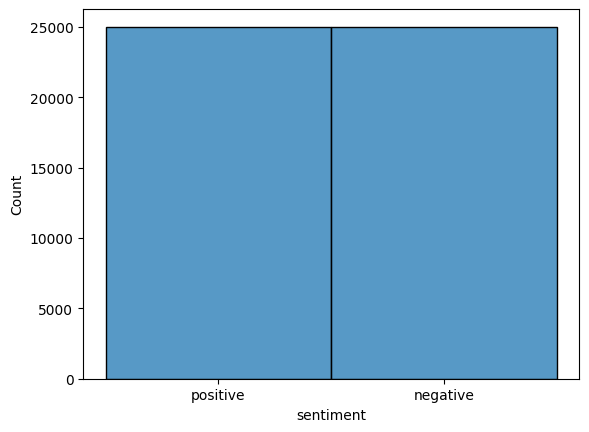

In [80]:
sns.histplot(data=df1,x='sentiment')
plt.show()

In [81]:
df1['review_length']=df1['review'].apply(len)

In [82]:
df1["review_length_words"] = df1["review"].apply(lambda x: len(x.split()))

In [83]:
df1

,review,sentiment,review_length,review_length_words
0,One of the other reviewers has mentioned that ...,positive,1761,307
1,A wonderful little production. <br /><br />The...,positive,998,162
2,I thought this was a wonderful way to spend ti...,positive,926,166
3,Basically there's a family where a little boy ...,negative,748,138
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1317,230
...,...,...,...,...
49995,I thought this movie did a down right good job...,positive,1008,194
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative,642,112
49997,I am a Catholic taught in parochial elementary...,negative,1280,230
49998,I'm going to have to disagree with the previou...,negative,1234,212


In [84]:
df1.groupby("sentiment")[["review_length", "review_length_words"]].mean()

,review_length,review_length_words
sentiment,,
negative,1294.06436,229.46456
positive,1324.79768,232.84932


In [85]:
df1['review_length'].skew()

np.float64(2.1839245817754165)

In [86]:
df1['review_length_words'].skew()

np.float64(2.1683033583491094)

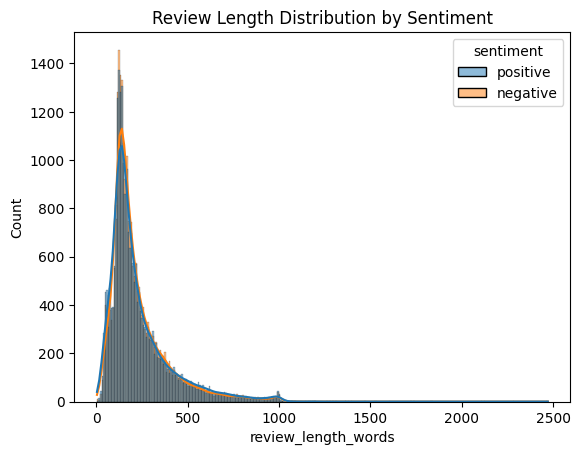

In [87]:
sns.histplot(data=df1, x="review_length_words", hue="sentiment", kde=True)
plt.title("Review Length Distribution by Sentiment")
plt.show()

In [92]:
import collections
word_counts = collections.Counter(word for review in df1['review'] for word in review.split())
top_20_words = word_counts.most_common(20)
print("Top 20 most common words:")
for word, count in top_20_words:
    print(f"'{word}': {count}")

Top 20 most common words:
'the': 568735
'a': 306960
'and': 301919
'of': 283625
'to': 261850
'is': 203056
'in': 169981
'I': 132498
'that': 126818
'this': 113726
'it': 107916
'/><br': 100974
'was': 92658
'as': 83130
'with': 82569
'for': 80919
'The': 67317
'but': 66282
'on': 61197
'movie': 60762


In [93]:
df1.loc[df1['review_length'].idxmin()]

review                 Read the book, forget the movie!
sentiment                                      negative
review_length                                        32
review_length_words                                   6
Name: 27521, dtype: object

In [37]:
df1.loc[df1['review_length'].idxmax()]

review                       Match 1: Tag Team Table Match Bubba Ray and Sp...
sentiment                                                             positive
review_length                                                            13704
review_length_words                                                       2470
review_length_words_spacy                                                 2530
Name: 31481, dtype: object

In [94]:
df1.duplicated().sum()

np.int64(418)

In [95]:

duplicates = df1['review'].duplicated().sum()
print(f"Number of duplicate reviews: {duplicates}")

if duplicates > 0:
    duplicate_reviews = df1[df1['review'].duplicated(keep=False)].sort_values('review')
    print(f"\nTotal rows with duplicates: {len(duplicate_reviews)}")
    print(duplicate_reviews.head(10))

Number of duplicate reviews: 418

Total rows with duplicates: 824
                                                  review sentiment  \
34058  "Go Fish" garnered Rose Troche rightly or wron...  negative   
47467  "Go Fish" garnered Rose Troche rightly or wron...  negative   
29956  "Three" is a seriously dumb shipwreck movie. M...  negative   
31488  "Three" is a seriously dumb shipwreck movie. M...  negative   
47527  "Witchery" might just be the most incoherent a...  negative   
2976   "Witchery" might just be the most incoherent a...  negative   
7949   'Dead Letter Office' is a low-budget film abou...  negative   
32260  'Dead Letter Office' is a low-budget film abou...  negative   
18022  (Spoilers)<br /><br />Oh sure it's based on Mo...  negative   
22449  (Spoilers)<br /><br />Oh sure it's based on Mo...  negative   

       review_length  review_length_words  
34058            743                  131  
47467            743                  131  
29956           2239           

In [97]:
# Remove duplicate reviews from df1
df1 = df1.drop_duplicates(subset=['review'], keep='first')

print(f"Shape after removing duplicates: {df1.shape}")
print(f"Duplicate reviews remaining: {df1['review'].duplicated().sum()}")

Shape after removing duplicates: (49582, 4)
Duplicate reviews remaining: 0


In [98]:
df1.duplicated().sum()

np.int64(0)

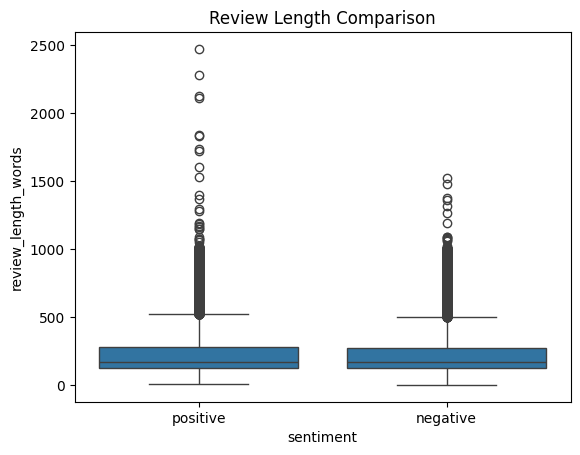

In [99]:
sns.boxplot(data=df1, x="sentiment", y="review_length_words")
plt.title("Review Length Comparison")
plt.show()

In [100]:
Q1 = df1['review_length_words'].quantile(0.25)
Q3 = df1['review_length_words'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df1 = df1[(df1['review_length_words'] >= lower_bound) & 
               (df1['review_length_words'] <= upper_bound)]

In [101]:
df1

,review,sentiment,review_length,review_length_words
0,One of the other reviewers has mentioned that ...,positive,1761,307
1,A wonderful little production. <br /><br />The...,positive,998,162
2,I thought this was a wonderful way to spend ti...,positive,926,166
3,Basically there's a family where a little boy ...,negative,748,138
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1317,230
...,...,...,...,...
49995,I thought this movie did a down right good job...,positive,1008,194
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative,642,112
49997,I am a Catholic taught in parochial elementary...,negative,1280,230
49998,I'm going to have to disagree with the previou...,negative,1234,212


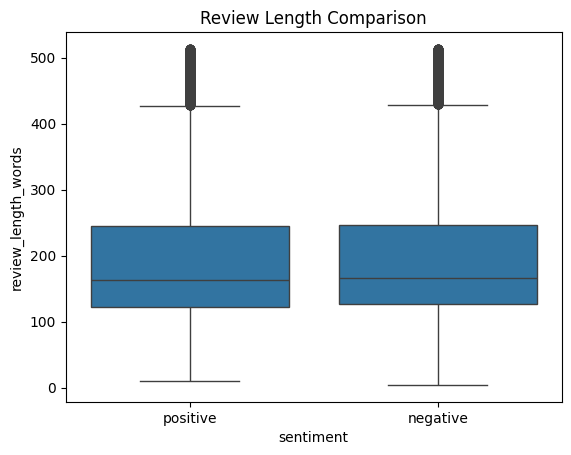

In [102]:
sns.boxplot(data=df1, x="sentiment", y="review_length_words")
plt.title("Review Length Comparison")
plt.show()

Sentiment Distribution in Balanced Dataset:
sentiment
negative    23020
positive    22901
Name: count, dtype: int64

Percentage Distribution:
sentiment
negative    50.13
positive    49.87
Name: count, dtype: float64


C:\Users\Harsh\AppData\Local\Temp\ipykernel_26848\3738225464.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='Set2')


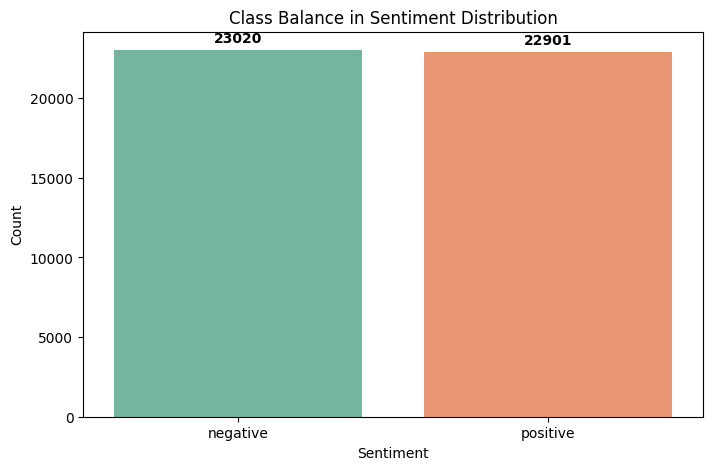

In [104]:
# Check class distribution in the balanced dataset
sentiment_counts = df1['sentiment'].value_counts()
print("Sentiment Distribution in Balanced Dataset:")
print(sentiment_counts)
print("\nPercentage Distribution:")
print((sentiment_counts / len(df1) * 100).round(2))

# Visualize class balance
plt.figure(figsize=(8, 5))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='Set2')
plt.title("Class Balance in Sentiment Distribution")
plt.ylabel("Count")
plt.xlabel("Sentiment")
for i, v in enumerate(sentiment_counts.values):
    plt.text(i, v + 500, str(v), ha='center', fontweight='bold')
plt.show()

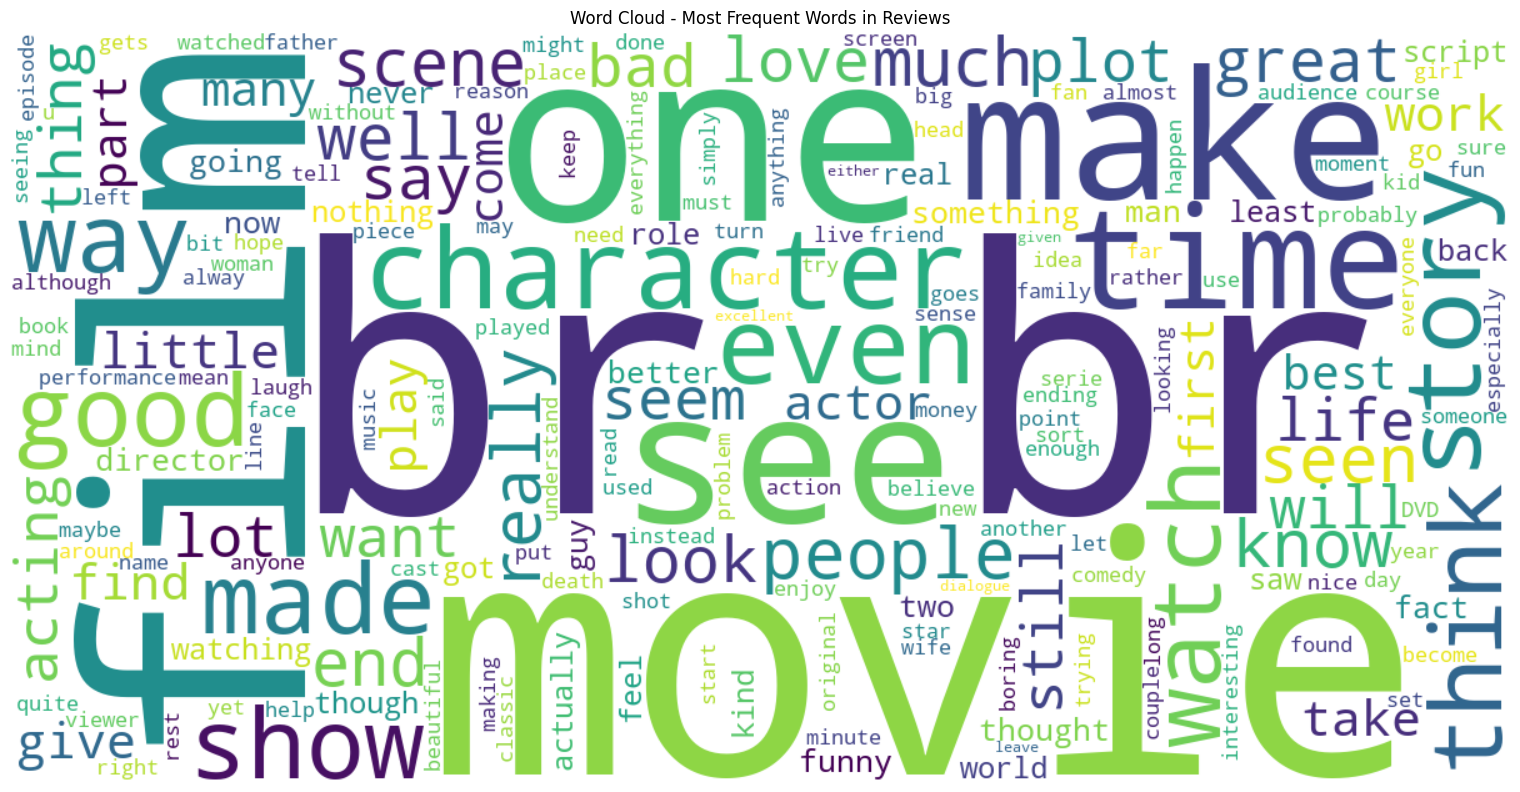

In [108]:
from wordcloud import WordCloud

# Generate wordcloud from the balanced dataset
wordcloud = WordCloud(width=1200, height=600, background_color='white').generate(' '.join(df1['review']))

plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Most Frequent Words in Reviews')
plt.tight_layout(pad=0)
plt.show()

In [109]:
df2=pd.read_csv("Reviews.csv")

In [110]:
df2.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [111]:
df2.tail()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
568449,568450,B001EO7N10,A28KG5XORO54AY,Lettie D. Carter,0,0,5,1299628800,Will not do without,Great for sesame chicken..this is a good if no...
568450,568451,B003S1WTCU,A3I8AFVPEE8KI5,R. Sawyer,0,0,2,1331251200,disappointed,I'm disappointed with the flavor. The chocolat...
568451,568452,B004I613EE,A121AA1GQV751Z,"pksd ""pk_007""",2,2,5,1329782400,Perfect for our maltipoo,"These stars are small, so you can give 10-15 o..."
568452,568453,B004I613EE,A3IBEVCTXKNOH,"Kathy A. Welch ""katwel""",1,1,5,1331596800,Favorite Training and reward treat,These are the BEST treats for training and rew...
568453,568454,B001LR2CU2,A3LGQPJCZVL9UC,srfell17,0,0,5,1338422400,Great Honey,"I am very satisfied ,product is as advertised,..."


In [112]:
df2.isnull().sum()

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

In [113]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [114]:
df2.duplicated().sum()

np.int64(0)

In [115]:
df2.describe()

,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,568454.000000,568454.000000,568454.00000,568454.000000,5.684540e+05
mean,284227.500000,1.743817,2.22881,4.183199,1.296257e+09
std,164098.679298,7.636513,8.28974,1.310436,4.804331e+07
min,1.000000,0.000000,0.00000,1.000000,9.393408e+08
25%,142114.250000,0.000000,0.00000,4.000000,1.271290e+09
50%,284227.500000,0.000000,1.00000,5.000000,1.311120e+09
75%,426340.750000,2.000000,2.00000,5.000000,1.332720e+09
max,568454.000000,866.000000,923.00000,5.000000,1.351210e+09


In [116]:
df2.dropna(inplace=True)

In [117]:
df2.drop(["Id","ProductId", "UserId","ProfileName"], axis=1, inplace=True)

df2.drop(['HelpfulnessNumerator', 'HelpfulnessDenominator'], axis=1, inplace=True)

df2.drop("Time",axis=1,inplace=True)




In [118]:
df2['Score'].unique()

array([5, 1, 4, 2, 3])

In [119]:
def score_to_sentiment(score):
    if score ==1 or score == 2:
        return 'negative'
    elif score == 4 or score == 5:
        return 'positive'   
    elif score == 3:
        return 'neutral'

df2['sentiment'] = df2['Score'].apply(score_to_sentiment)

In [120]:
df2

,Score,Summary,Text,sentiment
0,5,Good Quality Dog Food,I have bought several of the Vitality canned d...,positive
1,1,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,negative
2,4,"""Delight"" says it all",This is a confection that has been around a fe...,positive
3,2,Cough Medicine,If you are looking for the secret ingredient i...,negative
4,5,Great taffy,Great taffy at a great price. There was a wid...,positive
...,...,...,...,...
568449,5,Will not do without,Great for sesame chicken..this is a good if no...,positive
568450,2,disappointed,I'm disappointed with the flavor. The chocolat...,negative
568451,5,Perfect for our maltipoo,"These stars are small, so you can give 10-15 o...",positive
568452,5,Favorite Training and reward treat,These are the BEST treats for training and rew...,positive


In [121]:
df2['sentiment'].value_counts()

sentiment
positive    443756
negative     82007
neutral      42638
Name: count, dtype: int64

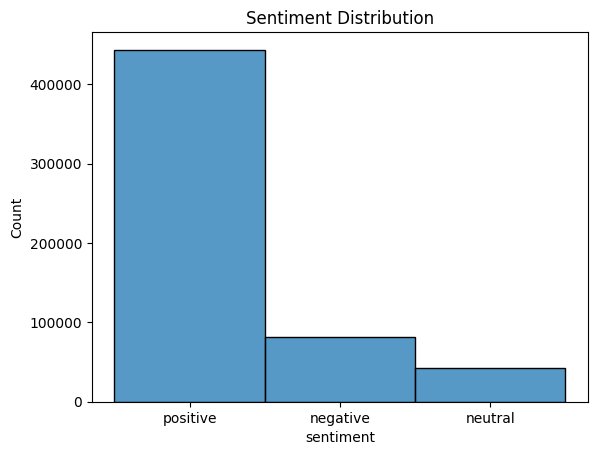

In [122]:
sns.histplot(data=df2,x='sentiment')
plt.title("Sentiment Distribution")
plt.show()

In [123]:
df2['review_length'] = df2['Text'].apply(len)
df2['review_length_words'] = df2['Text'].apply(lambda x: len(str(x).split()))

print(df2[['review_length', 'review_length_words']].describe())
print("\nAverage review lengths by sentiment:")
print(df2.groupby('sentiment')[['review_length', 'review_length_words']].mean())

       review_length  review_length_words
count  568401.000000        568401.000000
mean      436.246170            80.268277
std       445.351629            79.457515
min        12.000000             3.000000
25%       179.000000            33.000000
50%       302.000000            56.000000
75%       527.000000            98.000000
max     21409.000000          3432.000000

Average review lengths by sentiment:
           review_length  review_length_words
sentiment                                    
negative      482.757594            88.329265
neutral       520.337680            95.648881
positive      419.570888            77.300755


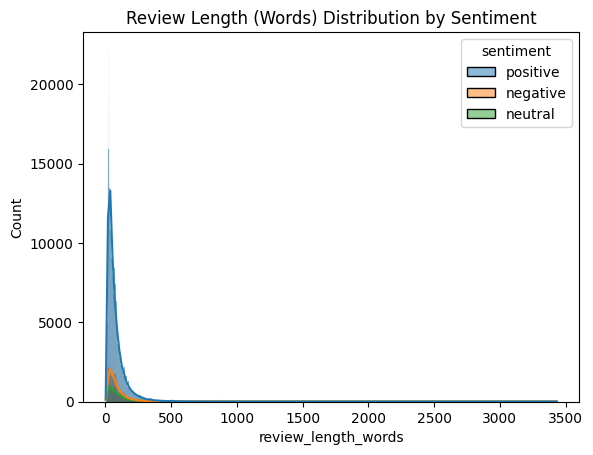

In [124]:
sns.histplot(data=df2, x='review_length_words', hue='sentiment', kde=True)
plt.title("Review Length (Words) Distribution by Sentiment")
plt.show()

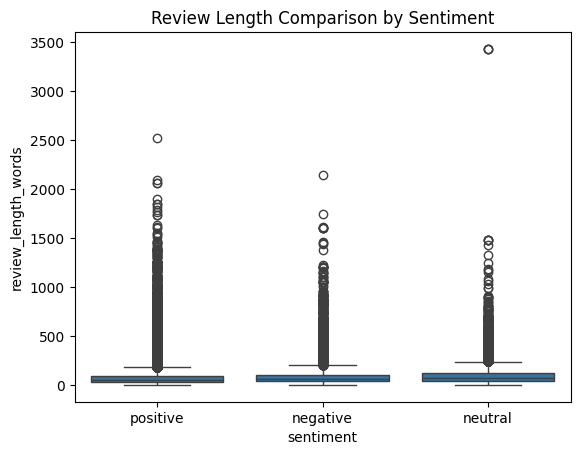

In [125]:
sns.boxplot(data=df2, x='sentiment', y='review_length_words')
plt.title("Review Length Comparison by Sentiment")
plt.show()

In [126]:
Q1 = df2['review_length_words'].quantile(0.25)
Q3 = df2['review_length_words'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df2 = df2[
    (df2['review_length_words'] >= lower_bound) &
    (df2['review_length_words'] <= upper_bound)
]



In [127]:
print(df2.shape)

(531217, 6)


In [128]:
df2 = df2[df2['review_length_words'] > 3]

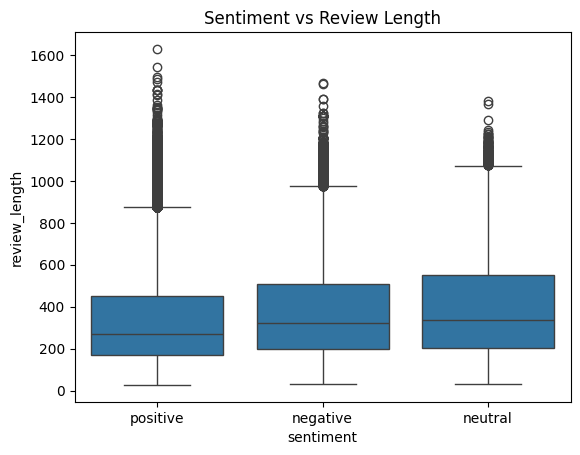

In [129]:
sns.boxplot(data=df2, x='sentiment', y='review_length')
plt.title("Sentiment vs Review Length")
plt.show()

In [130]:
from collections import Counter

In [131]:
overall_word_counts = Counter(word for review in df2['Text'] for word in review.split())
top_20_overall = overall_word_counts.most_common(20)
print("Top 20 most frequent words overall:")
for word, count in top_20_overall:
	print(f"'{word}': {count}")



Top 20 most frequent words overall:
'the': 1200530
'I': 1097743
'and': 943719
'a': 883562
'to': 735692
'of': 565559
'is': 559307
'it': 490772
'for': 404843
'this': 393363
'in': 382223
'my': 284205
'that': 282210
'have': 262577
'but': 255485
'with': 252576
'are': 248415
'was': 236120
'not': 221803
'you': 208602


In [132]:

negative_reviews = df2[df2['sentiment'] == 'negative']['Text']
negative_word_counts = Counter(word for review in negative_reviews for word in review.split())
top_20_negative = negative_word_counts.most_common(20)
print("\nTop 20 most frequent words in negative reviews:")
for word, count in top_20_negative:
	print(f"'{word}': {count}")


Top 20 most frequent words in negative reviews:
'the': 207773
'I': 186234
'and': 127943
'a': 116140
'to': 113131
'of': 93650
'it': 78041
'is': 72317
'this': 69001
'was': 56638
'in': 55100
'not': 52637
'for': 50663
'that': 47833
'but': 44035
'my': 37981
'have': 36957
'with': 33999
'like': 33727
'are': 29555


In [133]:
# Check class distribution
sentiment_counts = df2['sentiment'].value_counts()
print("Sentiment Distribution:")
print(sentiment_counts)
print("\nPercentage Distribution:")
print((sentiment_counts / len(df2) * 100).round(2))



Sentiment Distribution:
sentiment
positive    416799
negative     75964
neutral      38452
Name: count, dtype: int64

Percentage Distribution:
sentiment
positive    78.46
negative    14.30
neutral      7.24
Name: count, dtype: float64


C:\Users\Harsh\AppData\Local\Temp\ipykernel_26848\1982969140.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='Set2')


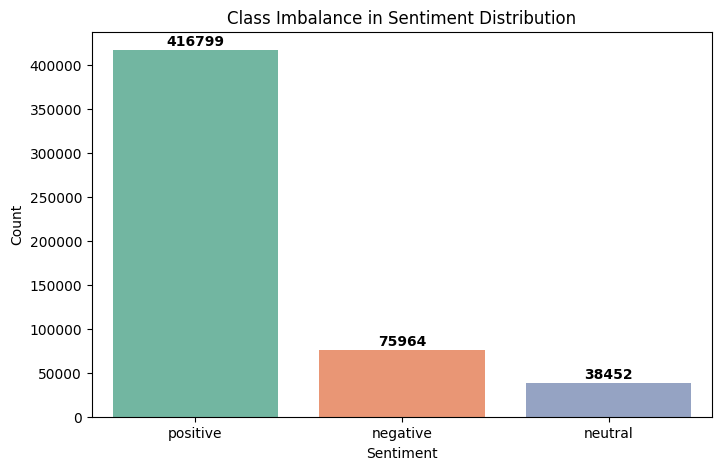

In [134]:

plt.figure(figsize=(8, 5))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='Set2')
plt.title("Class Imbalance in Sentiment Distribution")
plt.ylabel("Count")
plt.xlabel("Sentiment")
for i, v in enumerate(sentiment_counts.values):
    plt.text(i, v + 5000, str(v), ha='center', fontweight='bold')
plt.show()

In [135]:

df_positive = df2[df2['sentiment'] == 'positive']
df_negative = df2[df2['sentiment'] == 'negative']
df_neutral = df2[df2['sentiment'] == 'neutral']


min_count = min(len(df_positive), len(df_negative), len(df_neutral))


df_positive_sampled = df_positive.sample(n=min_count, random_state=42)
df_negative_sampled = df_negative.sample(n=min_count, random_state=42)
df_neutral_sampled = df_neutral.sample(n=min_count, random_state=42)




In [136]:
df_balanced = pd.concat([df_positive_sampled, df_negative_sampled, df_neutral_sampled])


df= df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

In [141]:

print("Total word count in balanced dataset:")
print(f"Total words: {df['Text'].apply(lambda x: len(x.split())).sum()}")

print("\nWord count by sentiment:")
for sentiment in df['sentiment'].unique():
    word_count = df[df['sentiment'] == sentiment]['Text'].apply(lambda x: len(x.split())).sum()
    print(f"{sentiment}: {word_count}")

Total word count in balanced dataset:
Total words: 7962528

Word count by sentiment:
neutral: 2849668
negative: 2696234
positive: 2416626


In [142]:
df.head(1)

,Score,Summary,Text,sentiment,review_length,review_length_words
0,3,BPA Free Cans,BPA free can a BIG plus if you eat/store canne...,neutral,367,65


In [143]:
df2.drop('Score',axis=1,inplace=True)

In [144]:
df2['final_text'] = df2['Summary'] + " " + df2['Text']

In [145]:
df2['final_text'] = df2['final_text'].str.lower()
df2['final_text'] = df2['final_text'].str.replace(r'[^a-zA-Z\s]', '', regex=True)
df2['final_text'] = df2['final_text'].str.replace(r'\s+', ' ', regex=True)

In [146]:
df2.drop(['Summary', 'Text'], axis=1, inplace=True)

In [147]:
df2 = df2[df2['final_text'].str.strip() != ""]

In [149]:
df1.rename(columns={'review': 'text'}, inplace=True)

In [150]:
df2.rename(columns={'final_text': 'text'}, inplace=True)

In [151]:
df1.columns

Index(['text', 'sentiment', 'review_length', 'review_length_words'], dtype='object')

In [152]:
df2.columns

Index(['sentiment', 'review_length', 'review_length_words', 'text'], dtype='object')

In [153]:
df1 = df1[['text', 'sentiment']]
df2 = df2[['text', 'sentiment']]

In [154]:
df = pd.concat([df1, df2], ignore_index=True)

In [157]:
import os
os.makedirs('../data', exist_ok=True)

In [158]:
df.to_csv('../data/final_dataset.csv', index=False)